In [1]:
import torch
import matplotlib.pyplot as plt

In [42]:
max_timesteps = 1000
betas = torch.linspace(1e-4, 2e-2, max_timesteps)

# α = how much signal survives
# β = how much noise is injected

alphas = 1 - betas

alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars

tensor([9.9990e-01, 9.9978e-01, 9.9964e-01, 9.9948e-01, 9.9930e-01, 9.9910e-01,
        9.9888e-01, 9.9864e-01, 9.9838e-01, 9.9811e-01, 9.9781e-01, 9.9749e-01,
        9.9715e-01, 9.9679e-01, 9.9641e-01, 9.9602e-01, 9.9560e-01, 9.9516e-01,
        9.9471e-01, 9.9423e-01, 9.9374e-01, 9.9322e-01, 9.9269e-01, 9.9213e-01,
        9.9156e-01, 9.9097e-01, 9.9035e-01, 9.8972e-01, 9.8907e-01, 9.8840e-01,
        9.8771e-01, 9.8700e-01, 9.8627e-01, 9.8553e-01, 9.8476e-01, 9.8398e-01,
        9.8317e-01, 9.8235e-01, 9.8151e-01, 9.8065e-01, 9.7977e-01, 9.7887e-01,
        9.7795e-01, 9.7702e-01, 9.7606e-01, 9.7509e-01, 9.7410e-01, 9.7309e-01,
        9.7206e-01, 9.7102e-01, 9.6995e-01, 9.6887e-01, 9.6777e-01, 9.6665e-01,
        9.6551e-01, 9.6436e-01, 9.6319e-01, 9.6200e-01, 9.6079e-01, 9.5956e-01,
        9.5832e-01, 9.5706e-01, 9.5578e-01, 9.5449e-01, 9.5318e-01, 9.5185e-01,
        9.5050e-01, 9.4914e-01, 9.4776e-01, 9.4636e-01, 9.4494e-01, 9.4351e-01,
        9.4207e-01, 9.4060e-01, 9.3912e-

In [ ]:
import cv2

img = cv2.cvtColor(cv2.resize(cv2.imread("sample_image.jpg"), (500,500)), cv2.COLOR_BGR2RGB)
img = torch.tensor(img, dtype=torch.float32) / 255.0
noise = torch.randn_like(img)

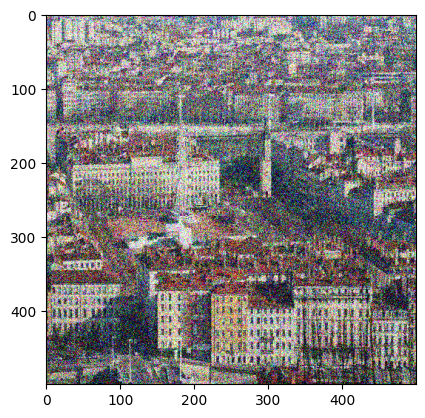

In [52]:
t = 83
noisy_image = (torch.sqrt(alpha_bars[t]) * img) + (torch.sqrt(1 - alpha_bars[t]) * noise)
plt.imshow(noisy_image.clamp(0, 1))

In [ ]:
class DDPM:
    """
    DDPM Scheduler
    

    # alphas = how much signal survives
    # betas  = how much noise is injected

    """

    def __init__(self, betas_start, betas_end, max_timesteps: int = 1000):
        self.max_timesteps = max_timesteps
        self.betas = torch.linspace(betas_start, betas_end, max_timesteps) 

        self.alphas = 1. - self.betas

        self.alpha_bars_cumprod = torch.cumprod(self.alphas, dim=0)

        self.alpha_bars_sqrt          = torch.sqrt(self.alpha_bars_cumprod)
        self._1_minus_alpha_bars_sqrt = torch.sqrt(1 - self.alpha_bars_cumprod)

    def add_noise(self, x0: torch.Tensor, t: torch.Tensor):
        # x0: [B, C, H, W]
        # t : [B, ]

        noise = torch.randn_like(x0)
        x_t = (self.alpha_bars_sqrt[t].view(-1, 1, 1, 1).to(x0.device) * x0) + (self._1_minus_alpha_bars_sqrt[t].view(-1, 1, 1, 1).to(x0.device) * noise)
        return x_t, noise

    def remove_noise(self, xt: torch.Tensor, t: torch.Tensor, noise: torch.Tensor):
        # x0: [B, C, H, W]
        # t : [B, ]

        return (xt - (self._1_minus_alpha_bars_sqrt[t].view(-1, 1, 1, 1).to(xt.device) * noise)) / self._1_minus_alpha_bars_sqrt[t].view(-1, 1, 1, 1).to(xt.device)[t]

/var/folders/3p/xlr6tgyx4t980qpxnnrs12kc0000gn/T/ipykernel_73237/834600047.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x0 = torch.tensor(x0).permute(-1, 0, 1).unsqueeze(0)


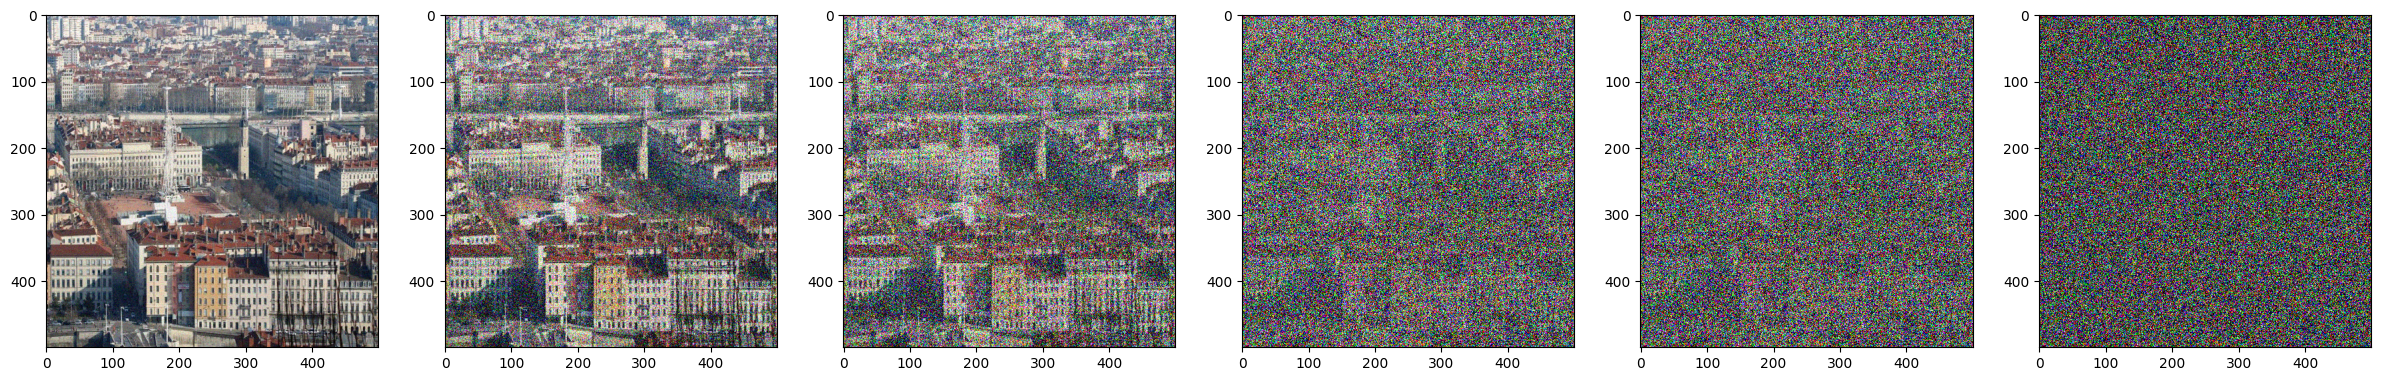

In [109]:
ddpm = DDPM(betas_start = 1e-4, betas_end = 1e-2, max_timesteps = 1000)

x0 = cv2.cvtColor(cv2.resize(cv2.imread("sample_image.jpg"), (500,500)), cv2.COLOR_BGR2RGB)
x0 = (torch.tensor(x0, dtype=torch.float32) / 255.0)

x0 = torch.tensor(x0).permute(-1, 0, 1).unsqueeze(0)

t = torch.asarray([10, 100, 200, 500, 600])

noisy_x0, noises = ddpm.add_noise(x0, t)


fix, axes = plt.subplots(1, 6, figsize = (30,30))

axes[0].imshow(noisy_x0[0].permute(1,2,0).clamp(0, 1).detach().cpu().numpy())
axes[1].imshow(noisy_x0[1].permute(1,2,0).clamp(0, 1).detach().cpu().numpy())
axes[2].imshow(noisy_x0[2].permute(1,2,0).clamp(0, 1).detach().cpu().numpy())
axes[3].imshow(noisy_x0[3].permute(1,2,0).clamp(0, 1).detach().cpu().numpy())
axes[4].imshow(noisy_x0[4].permute(1,2,0).clamp(0, 1).detach().cpu().numpy())
axes[5].imshow(noises[0].permute(1,2,0).clamp(0, 1).detach().cpu().numpy())

plt.show()

In [100]:
noises.shape

torch.Size([1, 3, 500, 500])

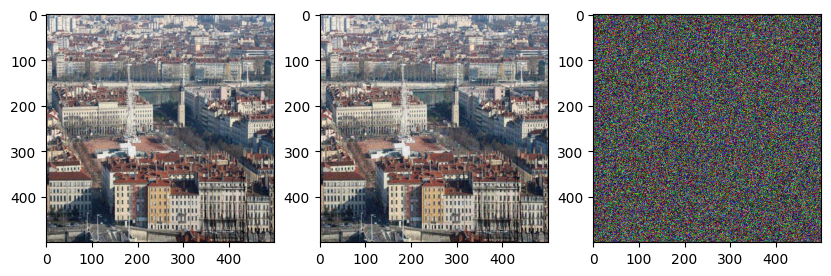